Theory

Zero-shot prompting asks the model to perform a task without any examples. It relies entirely on the model's pre-trained knowledge and instruction-following capabilities acquired during RLHF training.

The model generalizes from patterns learned during pre-training to handle novel tasks. The quality depends heavily on how clearly the task is specified, the specificity of the role or persona assigned, and the structural constraints provided (format, length, tone).

In LangGraph, zero-shot is the atomic unit — a single node that routes a prompt to an LLM and returns a response. All more complex patterns build on top of this primitive.

Key Principles

Be explicit about the task — ambiguity causes hallucinations

Assign a specific role/persona to activate domain priors

Specify output format constraints upfront (JSON, markdown, etc.)

Use imperative verbs: "Classify", "Extract", "Summarize"

Include negative constraints: "Do NOT include..."

Temperature should be low (0.0–0.3) for deterministic tasks

In [1]:
# ─────────────────────────────────────────────────────────
# Zero-Shot Prompting with LangGraph
# Pattern: Linear pipeline — Input → Prompt → LLM → Output
# ─────────────────────────────────────────────────────────

from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
import json
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# ── State Schema ──────────────────────────────────────────
class ZeroShotState(TypedDict):
    task: str                    # Raw task description
    role: str                    # Persona to adopt
    output_format: str           # Expected format (json/markdown/text)
    constraints: list[str]       # Negative constraints
    built_prompt: str            # Constructed prompt
    raw_response: str            # LLM raw output
    final_output: dict | str     # Parsed final result
    error: Optional[str]         # Error tracking


In [3]:
# ── LLM Setup ─────────────────────────────────────────────
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0.1,          # Low temp for deterministic zero-shot
    max_tokens=2048
)

In [ ]:
# ── Node 1: Build Prompt ──────────────────────────────────
def build_prompt(state: ZeroShotState) -> ZeroShotState:
    """
    Constructs a structured zero-shot prompt using:
    - Role assignment (activates domain-specific priors)
    - Task decomposition  
    - Format specification
    - Negative constraints
    """
    constraints_text = "\n".join(
        [f"- Do NOT {c}" for c in state["constraints"]]
    ) if state["constraints"] else "None"
    #DO NOT include subjective opinions
    #DO NOT use vague categories

    format_instruction = {
        "json": "Respond ONLY with valid JSON. No markdown fences.",
        "markdown": "Use proper markdown with headers and lists.",
        "text": "Respond with clear, concise plain text.",
    }.get(state["output_format"], "Respond clearly.")

    prompt = f"""You are {state['role']}.

TASK:
{state['task']}

OUTPUT FORMAT:
{format_instruction}

CONSTRAINTS:
{constraints_text}

Begin your response now:"""

    return {**state, "built_prompt": prompt}

In [5]:
# ── Node 2: Call LLM ──────────────────────────────────────
def call_llm(state: ZeroShotState) -> ZeroShotState:
    """Sends prompt to LLM and captures raw response."""
    try:
        messages = [
            SystemMessage(content="Follow the user's instructions precisely."),
            HumanMessage(content=state["built_prompt"])
        ]
        response = llm.invoke(messages)
        return {**state, "raw_response": response.content, "error": None}
    except Exception as e:
        return {**state, "error": str(e), "raw_response": ""}

In [6]:
# ── Node 3: Format Output ─────────────────────────────────
def format_output(state: ZeroShotState) -> ZeroShotState:
    """Parses and validates the LLM response."""
    if state.get("error"):
        return {**state, "final_output": {"error": state["error"]}}

    raw = state["raw_response"].strip()

    if state["output_format"] == "json":
        try:
            parsed = json.loads(raw)
            return {**state, "final_output": parsed}
        except json.JSONDecodeError:
            # Strip markdown fences if model added them
            clean = raw.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(clean)
            return {**state, "final_output": parsed}

    return {**state, "final_output": raw}

In [7]:
# ── Graph Construction ────────────────────────────────────
def build_zero_shot_graph():
    builder = StateGraph(ZeroShotState)

    builder.add_node("build_prompt", build_prompt)
    builder.add_node("call_llm", call_llm)
    builder.add_node("format_output", format_output)

    builder.add_edge(START, "build_prompt")
    builder.add_edge("build_prompt", "call_llm")
    builder.add_edge("call_llm", "format_output")
    builder.add_edge("format_output", END)

    return builder.compile()

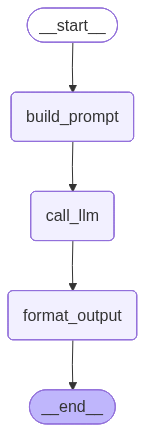

In [8]:
# ── Usage Example ─────────────────────────────────────────
from IPython.display import Image, display
graph = build_zero_shot_graph()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
result = graph.invoke({
    "task": "Classify this customer review sentiment and extract key themes: 'The product arrived late but the quality was exceptional. Customer support resolved my issue quickly.'",
    "role": "an expert sentiment analysis system for e-commerce",
    "output_format": "json",
    "constraints": ["include subjective opinions", "use vague categories"],
    "built_prompt": "",
    "raw_response": "",
    "final_output": {},
    "error": None
})
print(result["built_prompt"])
print("*"*100)
print(result["raw_response"])
print("*"*100)
print(result["final_output"])
# → {"sentiment": "mixed", "themes": ["delivery", "quality", "support"],
#    "scores": {"delivery": -0.7, "quality": 0.9, "support": 0.8}}

You are an expert sentiment analysis system for e-commerce.

TASK:
Classify this customer review sentiment and extract key themes: 'The product arrived late but the quality was exceptional. Customer support resolved my issue quickly.'

OUTPUT FORMAT:
Respond ONLY with valid JSON. No markdown fences.

CONSTRAINTS:
- Do NOT include subjective opinions
- Do NOT use vague categories

Begin your response now:
****************************************************************************************************
{
  "sentiment": "mixed",
  "key_themes": [
    "delivery timing",
    "product quality",
    "customer support"
  ]
}
****************************************************************************************************
{'sentiment': 'mixed', 'key_themes': ['delivery timing', 'product quality', 'customer support']}
